In [1]:
import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn
from mpl_toolkits import mplot3d

from plotly.offline import download_plotlyjs, init_notebook_mode
from plotly.offline import plot, iplot
import plotly.graph_objects as go
%matplotlib inline

In [2]:
#Creating a path 
path = r"/Users/tiffanib./Desktop/Career Foundry Data Analytics/Machine Learning with Python/Data Sets/"

In [3]:
path

'/Users/tiffanib./Desktop/Career Foundry Data Analytics/Machine Learning with Python/Data Sets/'

In [4]:
#importing climate data set
climatedf = pd.read_csv(os.path.join(path, "Dataset-weather-prediction-dataset-processed_scaled.csv"))

In [5]:
#reducing the mean temperatures
df = climatedf[['DATE','MONTH','BASEL_temp_mean',
 'BELGRADE_temp_mean',
 'BUDAPEST_temp_mean',
 'DEBILT_temp_mean',
 'DUSSELDORF_temp_mean',
 'GDANSK_temp_mean',
 'HEATHROW_temp_mean',
 'KASSEL_temp_mean',
 'LJUBLJANA_temp_mean',
 'MAASTRICHT_temp_mean',
 'MADRID_temp_mean',
 'MUNCHENB_temp_mean',
 'OSLO_temp_mean',
 'ROMA_temp_mean',
 'SONNBLICK_temp_mean',
 'STOCKHOLM_temp_mean',
 'TOURS_temp_mean',
 'VALENTIA_temp_mean']].copy()        

In [6]:
df

,DATE,MONTH,BASEL_temp_mean,BELGRADE_temp_mean,BUDAPEST_temp_mean,DEBILT_temp_mean,DUSSELDORF_temp_mean,GDANSK_temp_mean,HEATHROW_temp_mean,KASSEL_temp_mean,LJUBLJANA_temp_mean,MAASTRICHT_temp_mean,MADRID_temp_mean,MUNCHENB_temp_mean,OSLO_temp_mean,ROMA_temp_mean,SONNBLICK_temp_mean,STOCKHOLM_temp_mean,TOURS_temp_mean,VALENTIA_temp_mean
0,19600101,1,-0.528623,-1.016876,-1.099163,-0.114356,-0.105836,-0.927601,-0.106469,-0.182904,-1.370824,-0.097084,-0.988280,-0.265742,-0.186575,-1.280450,-0.124331,-0.391072,-0.257321,-0.668215
1,19600102,1,-0.582946,-1.107669,-1.110927,-0.367511,-0.370915,-0.825294,-0.892676,-0.212437,-1.043881,-0.232112,-0.691740,-0.353714,-0.368598,-0.539569,-0.650834,-0.415953,-0.335759,-0.548046
2,19600103,1,-0.257010,-1.084971,-1.063873,-0.509912,-0.532908,-0.940389,-0.490837,-0.389635,-0.741156,-0.487164,-0.853490,-0.403983,-0.550620,-0.876333,-0.650834,-0.615003,-0.210258,-0.067372
3,19600104,1,-0.555784,-1.209812,-1.146217,-0.525734,-0.577088,-1.042696,-0.316124,-0.493001,-0.910682,-0.472161,-0.624345,-0.642763,-0.417137,-0.775304,-0.943336,-0.764290,-0.069069,-0.998679
4,19600105,1,-1.003946,-1.209812,-1.087400,-0.320045,-0.444548,-0.978754,-0.403481,-0.552067,-0.862246,-0.307127,-0.381721,-0.906678,-0.332193,-0.926848,-0.621584,-0.503037,-0.037694,-1.509396
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22945,20221027,10,0.747959,0.628750,-0.005167,0.898267,1.042841,0.440753,0.906865,-0.005705,0.481853,1.268193,0.683127,0.664244,0.395898,-0.000746,0.826301,0.517090,1.295755,-0.007287
22946,20221028,10,0.856604,0.367720,-0.005167,0.945734,1.278467,0.466330,0.802037,-0.005705,0.263891,1.313202,0.561815,0.890456,0.541516,-0.000746,1.074927,0.641496,1.358505,-0.007287
22947,20221029,10,0.856604,0.083991,-0.005167,0.914089,1.101748,0.786039,0.924336,-0.005705,0.300218,1.208181,0.548336,1.053832,0.395898,-0.000746,1.221178,0.716139,1.405568,-0.007287
22948,20221030,10,0.680055,0.265577,-0.005167,0.692578,0.880848,0.376811,0.697210,-0.005705,0.397090,0.923123,0.103526,0.689378,-0.065226,-0.000746,1.235803,0.019467,0.668249,-0.007287


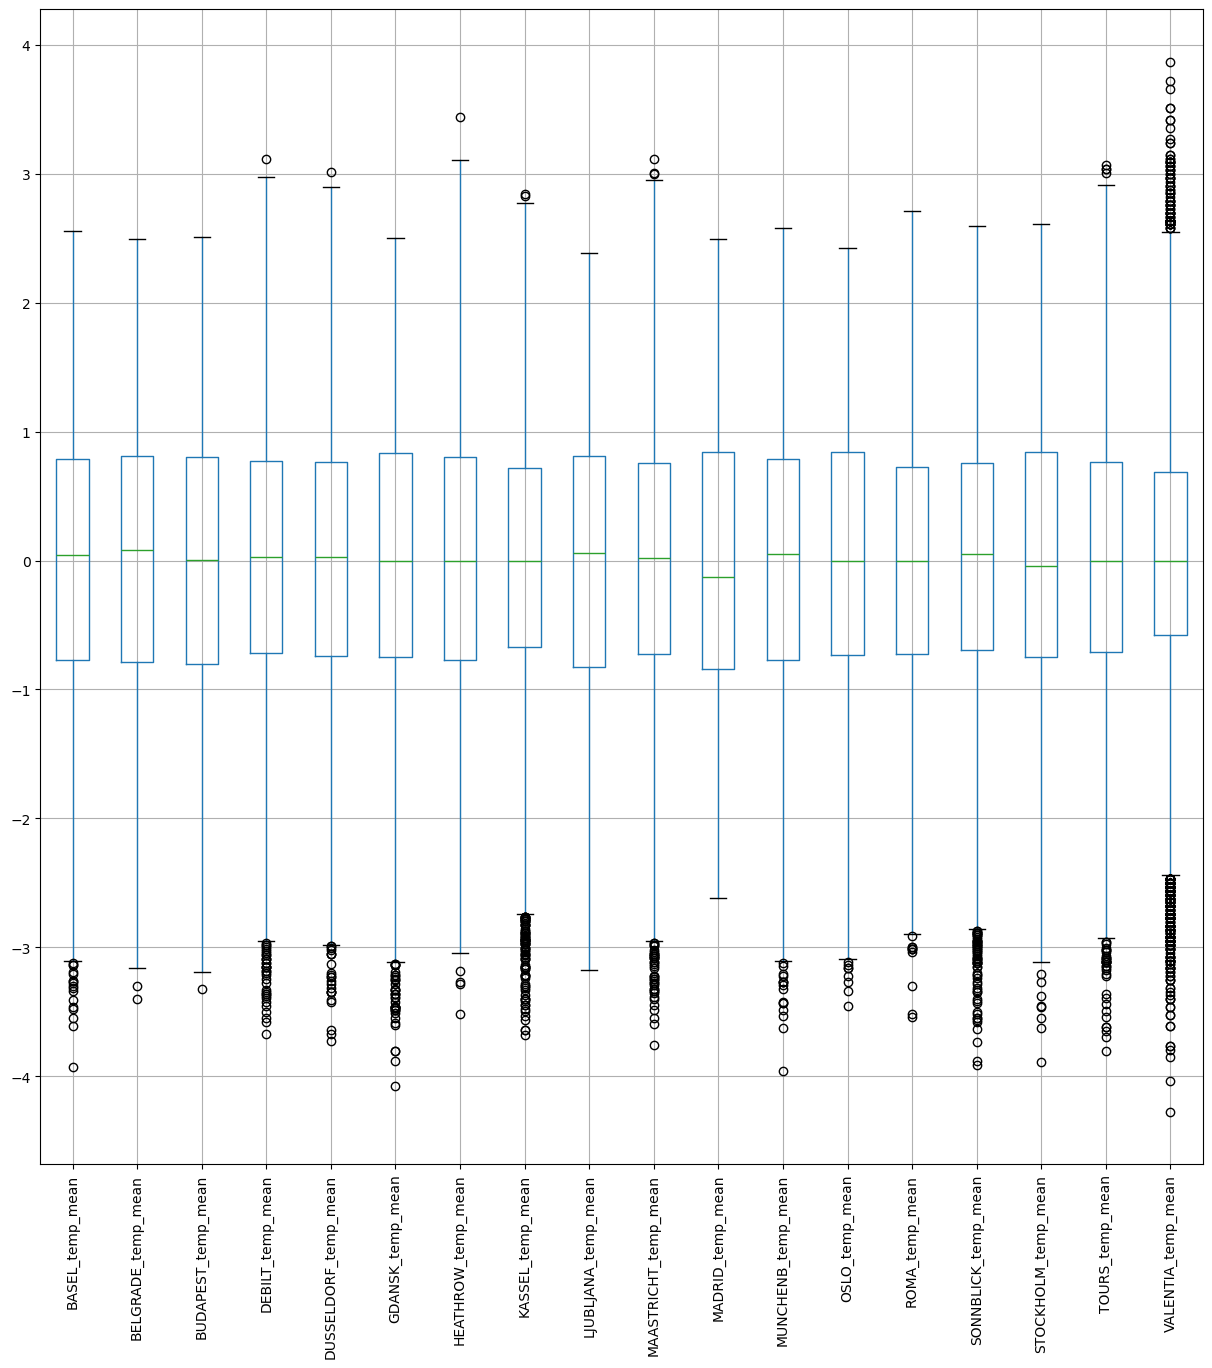

In [8]:
#Dropping the DATE and MONTH data as those numbers are not scaled with the rest.
notemp_year = df.drop(['DATE','MONTH'], axis=1)

plt.figure(figsize=(15,15))
notemp_year.boxplot()
plt.xticks(rotation=90)
plt.show()


In [9]:
#Reduce your dataset to a single year
dfyear = df[df['DATE'].astype(str).str.startswith('1988')]
dfyear = dfyear.head(365)

In [10]:
dfyear.describe()

,DATE,MONTH,BASEL_temp_mean,BELGRADE_temp_mean,BUDAPEST_temp_mean,DEBILT_temp_mean,DUSSELDORF_temp_mean,GDANSK_temp_mean,HEATHROW_temp_mean,KASSEL_temp_mean,LJUBLJANA_temp_mean,MAASTRICHT_temp_mean,MADRID_temp_mean,MUNCHENB_temp_mean,OSLO_temp_mean,ROMA_temp_mean,SONNBLICK_temp_mean,STOCKHOLM_temp_mean,TOURS_temp_mean,VALENTIA_temp_mean
count,3.650000e+02,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,1.988067e+07,6.498630,0.027291,-0.035128,-0.043422,0.055484,0.059506,-0.008521,-0.056879,0.041993,-0.015545,0.039382,-0.021848,-0.003790,-0.002391,-0.031747,-0.041108,-0.038612,0.017019,-0.011485
std,3.449727e+02,3.448702,0.872840,0.987548,0.963089,0.800882,0.846130,0.940654,0.852423,0.952228,0.972970,0.822225,0.937834,0.911165,0.989378,1.146838,1.025288,0.993951,0.836944,0.935835
min,1.988010e+07,1.000000,-2.266947,-2.060998,-2.040235,-1.854801,-1.931938,-2.078553,-1.818653,-2.324051,-2.303217,-1.822435,-1.689193,-2.314224,-2.516466,-2.526478,-2.888473,-2.194956,-2.108461,-2.831251
25%,1.988040e+07,4.000000,-0.705172,-0.926083,-0.899185,-0.589023,-0.650721,-0.876447,-0.787848,-0.788331,-0.886464,-0.652197,-0.799573,-0.818707,-0.793317,-0.994201,-0.782460,-0.863814,-0.665199,-0.698257
50%,1.988070e+07,7.000000,0.028184,-0.018151,-0.063984,0.059689,0.070884,-0.045204,-0.036584,0.038594,0.045929,0.082952,-0.085181,0.048442,-0.247249,-0.118614,0.065796,-0.154701,0.087807,0.082839
75%,1.988093e+07,9.000000,0.788701,0.776289,0.771218,0.724222,0.733582,0.849980,0.662267,0.806454,0.724033,0.713080,0.629210,0.727080,0.881292,0.874841,0.709300,0.927629,0.715312,0.743767
max,1.988123e+07,12.000000,2.173927,2.297075,2.006375,1.990001,2.029525,2.077662,1.850313,2.268341,1.934934,1.973336,2.057994,2.084357,2.337474,2.541824,2.054809,1.897994,1.829134,2.185791


In [11]:
#Picking which weather station I want to use. Below is a 3D visualization of the temperatures for that year.

In [12]:
#Drop the DATE and MONTH data as those numbers are not scaled with the rest.
notempyear = dfyear.drop(['DATE','MONTH'], axis=1)

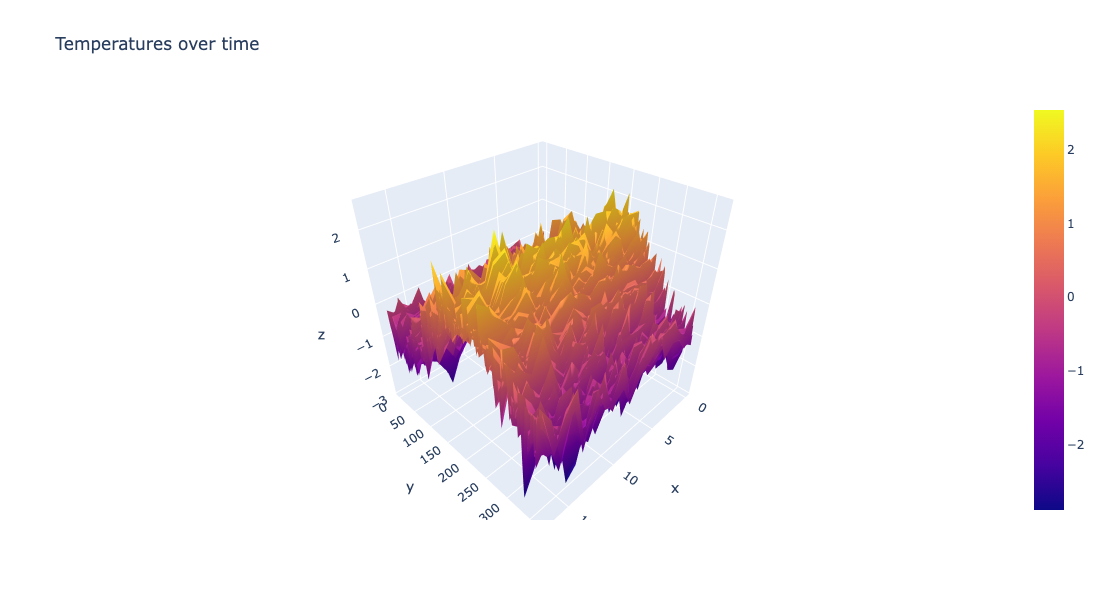

In [13]:
#Plotting all weather data for all stations for a year

#X = weather station
#Y = Day of the year
#Z = Temperature

fig = go.Figure(data=[go.Surface(z=notempyear.values)])
fig.update_layout(title='Temperatures over time', autosize=False,
                  width=600, height=600)
fig.show()

In [14]:
#creating an index for the year from 1 to 365 then scaling it by 100.
i = np.arange(0.01,3.66,0.01)
index = pd.DataFrame(data = i, columns = ['index'])
index

,index
0,0.01
1,0.02
2,0.03
3,0.04
4,0.05
...,...
360,3.61
361,3.62
362,3.63
363,3.64


In [15]:
n_rows = dfyear.shape[0]
n_rows

365

In [16]:
#translating weather data into the x and y datasets for optimization
X=index.to_numpy().reshape(n_rows,1)
ones = np.ones((n_rows,1))
X = np.concatenate((ones, X), axis=1)
y=dfyear['MADRID_temp_mean'].to_numpy().reshape(n_rows,1)

In [17]:
X.shape, y.shape

((365, 2), (365, 1))

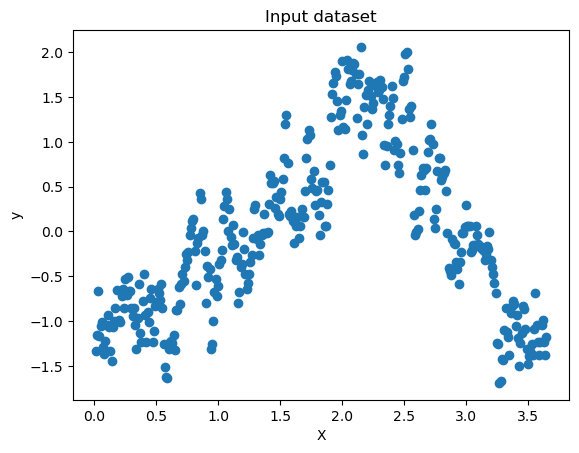

In [18]:
#visualizing 1965 weather year over time
plt.scatter(x=index['index'], y=dfyear['MADRID_temp_mean'])
plt.xlabel('X'); plt.ylabel('y');
plt.title('Input dataset');
plt.show()

In [19]:
#The mean temperature
dfyear['MADRID_temp_mean'].min()

-1.6891930894872644

In [20]:
#The max temperature
dfyear['MADRID_temp_mean'].max()

2.057993911109622

In [21]:
#Computing the loss function for the gradiant descent.

def compute_cost(X, y, theta=np.array([[0],[0]])):
    """Given covariate matrix X, the prediction results y and coefficients theta
    compute the loss"""
    
    m = len(y)
    J=0 # initialize loss to zero
    
    # reshape theta
    theta=theta.reshape(2,1)
    
    # calculate the hypothesis - y_hat
    h_x = np.dot(X,theta)
    #print(h_x)
    
    # subtract y from y_hat, square and sum
    error_term = sum((h_x - y)**2)
    
    # divide by twice the number of samples - standard practice.
    loss = error_term/(2*m)
    
    return loss

In [22]:
compute_cost(X,y)

array([0.43879969])

In [23]:
#This is the gradiant descent function. 

def gradient_descent(X, y, theta=np.array([[0],[0]]),
                    alpha=0.01, num_iterations=1500):
    """
    Solve for theta using Gradient Descent optimiztion technique. 
    Alpha is the learning rate
    """
    m = len(y)
    J_history = []
    theta0_history = []
    theta1_history = []
    theta = theta.reshape(2,1)
    
    for i in range(num_iterations):
        error = (np.dot(X, theta) - y)
        
        term0 = (alpha/m) * sum(error* X[:,0].reshape(m,1))
        term1 = (alpha/m) * sum(error* X[:,1].reshape(m,1))
        
        # update theta
        term_vector = np.array([[term0],[term1]])
        #print(term_vector)
        theta = theta - term_vector.reshape(2,1)
        
        # store history values
        theta0_history.append(theta[0].tolist()[0])
        theta1_history.append(theta[1].tolist()[0])
        J_history.append(compute_cost(X,y,theta).tolist()[0])
        
    return (theta, J_history, theta0_history, theta1_history)

In [24]:
%%time
#This runs your data through a gradiant descent for the starting conditions in 'theta_init.'

num_iterations=500 
theta_init=np.array([[-10],[-5]]) 
alpha=0.1 
theta, J_history, theta0_history, theta1_history = gradient_descent(X,y, theta_init,
                                                                   alpha, num_iterations)

CPU times: user 191 ms, sys: 6.42 ms, total: 197 ms
Wall time: 193 ms


In [25]:
theta

array([[-0.35782161],
       [ 0.18357564]])

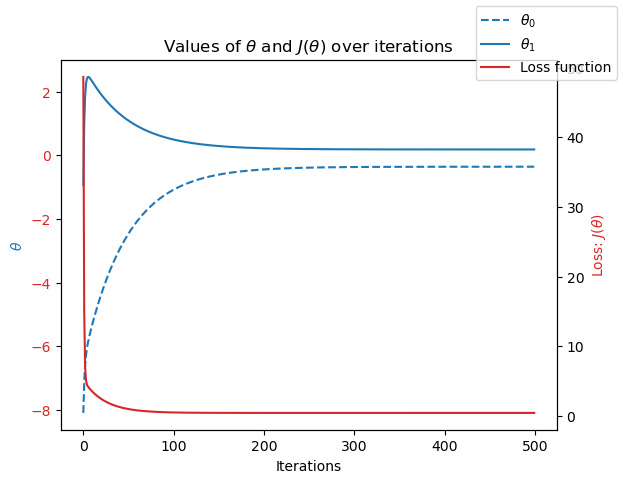

In [26]:
#plotting the loss, theta0, and theta1.

fig, ax1 = plt.subplots()

# plot thetas over time
color='tab:blue'
ax1.plot(theta0_history, label='$\\theta_{0}$', linestyle='--', color=color)
ax1.plot(theta1_history, label='$\\theta_{1}$', linestyle='-', color=color)
# ax1.legend()
ax1.set_xlabel('Iterations'); ax1.set_ylabel('$\\theta$', color=color);
ax1.tick_params(axis='y', labelcolor=color)

# plot loss function over time
color='tab:red'
ax2 = ax1.twinx()
ax2.plot(J_history, label='Loss function', color=color)
ax2.set_title('Values of $\\theta$ and $J(\\theta)$ over iterations')
ax2.set_ylabel('Loss: $J(\\theta)$', color=color)
ax1.tick_params(axis='y', labelcolor=color)

# ax2.legend();
fig.legend();

plt.show()


In [27]:
%%time
# theta range
theta0_vals = np.linspace(-10,10,100) 
theta1_vals = np.linspace(-10,10,100) 

J_vals = np.zeros((len(theta0_vals), len(theta1_vals)))

# compute cost for each combination of theta
c1=0; c2=0
for i in theta0_vals:
    for j in theta1_vals:
        t = np.array([i, j])
        J_vals[c1][c2] = compute_cost(X, y, t.transpose()).tolist()[0]
        c2=c2+1
    c1=c1+1
    c2=0 # reinitialize to 0

CPU times: user 1.17 s, sys: 39.9 ms, total: 1.21 s
Wall time: 1.18 s


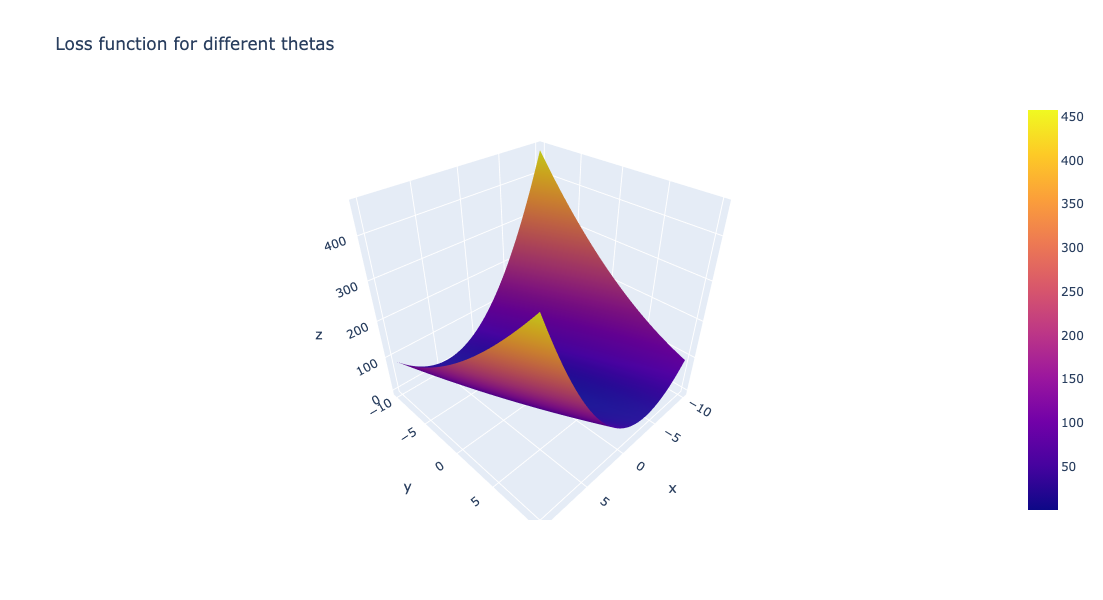

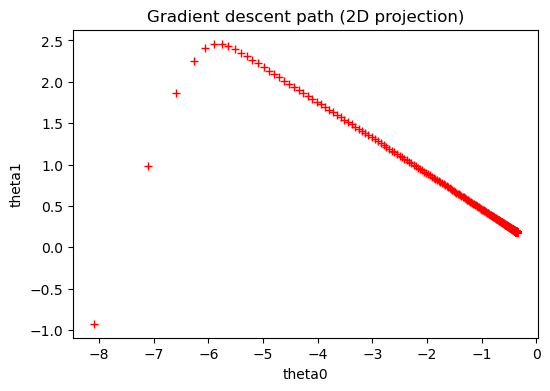

In [29]:
#this shows the loss function

#X = Theta0
#Y = Theta1
#Z = Loss
#Finding where it is closest to 0 in X and Y

fig = go.Figure(data=[go.Surface(x=theta1_vals, y=theta0_vals, z=J_vals)])
fig.update_layout(title='Loss function for different thetas', autosize=True,
                  width=600, height=600, xaxis_title='theta0', 
                 yaxis_title='theta1')
fig.show()
# ---------- Matplotlib 2D projection ----------
plt.figure(figsize=(6, 4))

plt.plot(theta0_history, theta1_history, 'r+')
plt.xlabel('theta0')
plt.ylabel('theta1')
plt.title('Gradient descent path (2D projection)')

plt.show()

In [30]:
#rerunning the optimization above.
num_iterations=500 
theta_init=np.array([[1],[1]]) 
alpha= 0.1 
theta1, J_history1, theta0_history1, theta1_history1 = gradient_descent(X,y, theta_init,
                                                                   alpha, num_iterations)

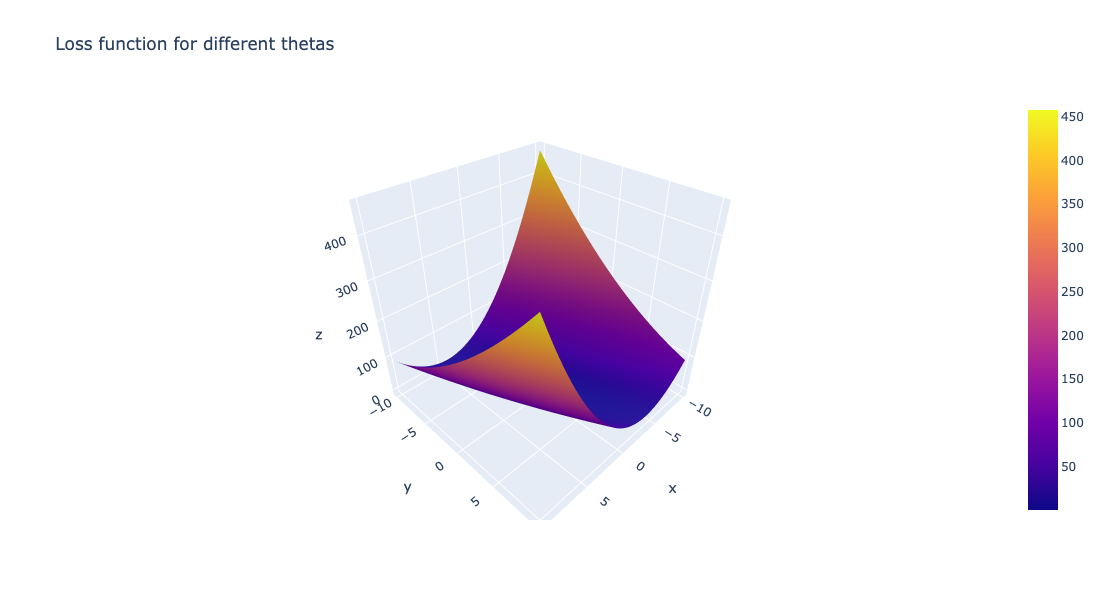

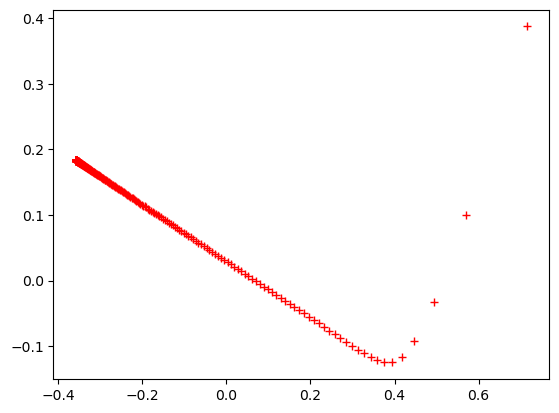

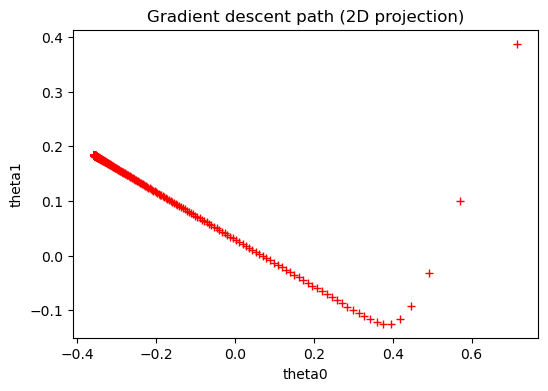

In [31]:
#New loss path on the function.
line_marker = dict(color='#101010', width=2)
fig = go.Figure()
fig.add_surface(x=theta1_vals, y=theta0_vals, z=J_vals)
fig.add_scatter3d(x=theta1_history1, y=theta0_history1, z=J_history1, line=line_marker, name='')
#The below line adds a graph of just the loss over iterations in a 2D plane
plt.plot(theta0_history1, theta1_history1, 'r+');
fig.update_layout(title='Loss function for different thetas', autosize=True,
                  width=600, height=600, xaxis_title='theta0', 
                 yaxis_title='theta1')
fig.show()
# ---------- Matplotlib 2D plot  ----------
plt.figure(figsize=(6, 4))

plt.plot(theta0_history1, theta1_history1, 'r+')
plt.xlabel('theta0')
plt.ylabel('theta1')
plt.title('Gradient descent path (2D projection)')

plt.show()

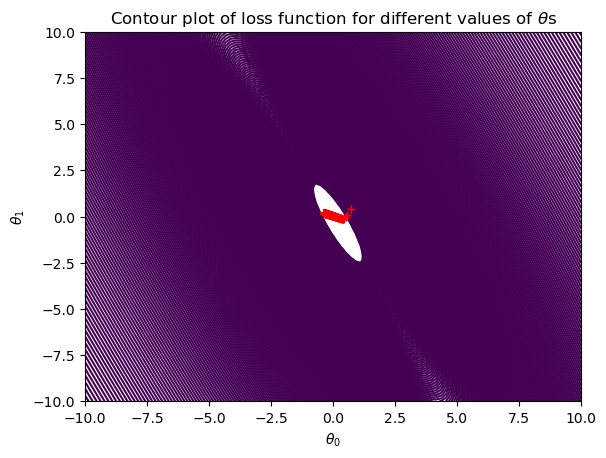

In [32]:
#this shows the convergence
plt.contour(theta0_vals, theta1_vals, J_vals, levels = np.logspace(0,10,1000))
plt.xlabel('$\\theta_{0}$'); plt.ylabel("$\\theta_{1}$")
plt.title("Contour plot of loss function for different values of $\\theta$s");
plt.plot(theta0_history1, theta1_history1, 'r+');

plt.show()